<a href="https://colab.research.google.com/github/gkhamis04/George-Khamis/blob/main/Inventory%20Demand%20Forecasting%20using%20Machine%20Learning%20-%20Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing important libraries**

In [16]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error as mse

In [17]:
df = pd.read_csv("train.csv")

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [19]:
df.shape

(913000, 4)

In [20]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [21]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [22]:
parts_of_date = df['date'].str.split("-", n=3, expand=True)
print(parts_of_date)

           0   1   2
0       2013  01  01
1       2013  01  02
2       2013  01  03
3       2013  01  04
4       2013  01  05
...      ...  ..  ..
912995  2017  12  27
912996  2017  12  28
912997  2017  12  29
912998  2017  12  30
912999  2017  12  31

[913000 rows x 3 columns]


In [23]:
df["year"]=parts_of_date[0].astype("int")
df["month"]= parts_of_date[1].astype("int")
df["day"]= parts_of_date[2].astype("int")
df.head()

,date,store,item,sales,year,month,day
0,2013-01-01,1,1,13,2013,1,1
1,2013-01-02,1,1,11,2013,1,2
2,2013-01-03,1,1,14,2013,1,3
3,2013-01-04,1,1,13,2013,1,4
4,2013-01-05,1,1,10,2013,1,5


In [24]:
df['weekend'] = (pd.to_datetime(df[['year', 'month', 'day']]).dt.weekday > 4).astype(int)


In [25]:
from datetime import date
import holidays

india_holidays = holidays.country_holidays('IN')
df['holidays'] = df['date'].apply(lambda x: 1 if india_holidays.get(x) else 0)

In [27]:
df.drop('date', axis=1, inplace=True)

**Exploratory Data Analysis**

In [28]:
df['store'].nunique(), df['item'].nunique()

(10, 50)

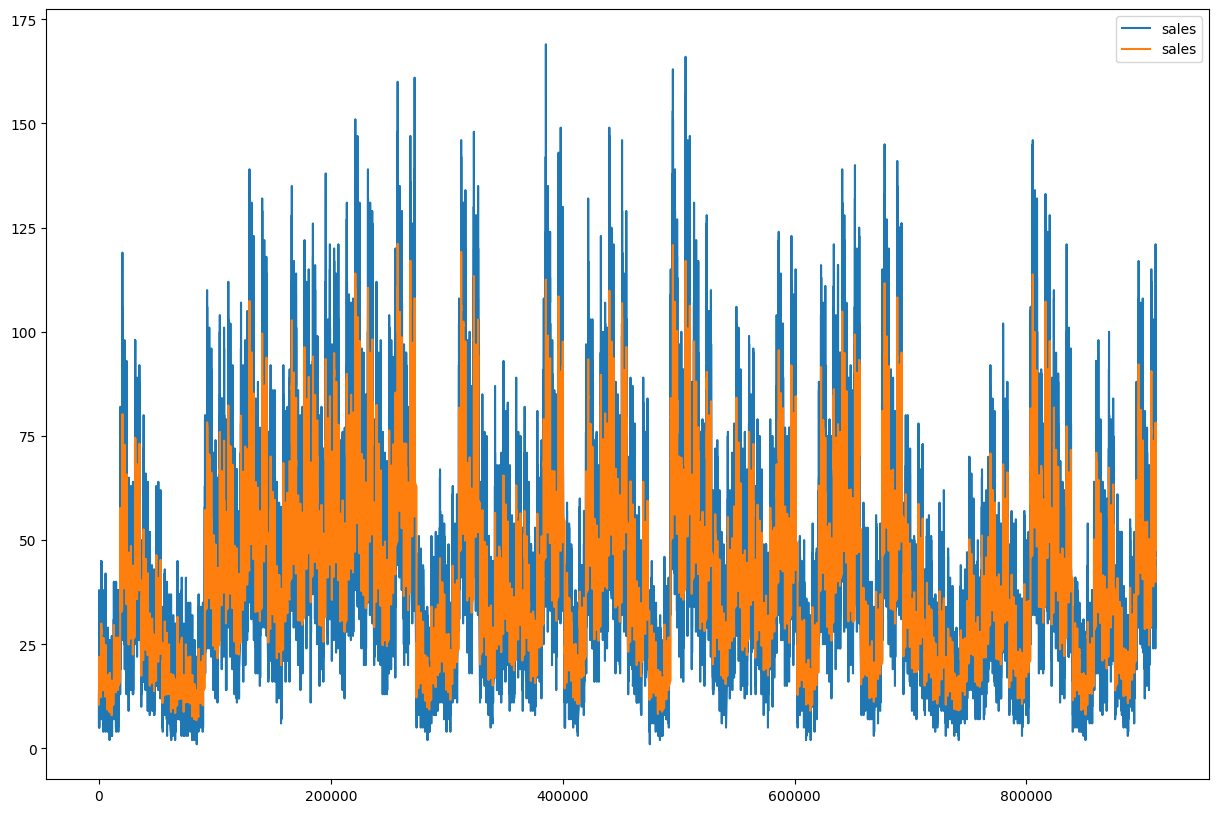

In [30]:
plt.figure(figsize=(15, 10))

window_size = 30
data = df[df['year']==2013]
windows = data['sales'].rolling(window_size)
sma = windows.mean()
sma = sma[window_size - 1:]

data['sales'].plot()
sma.plot()
plt.legend()
plt.show()

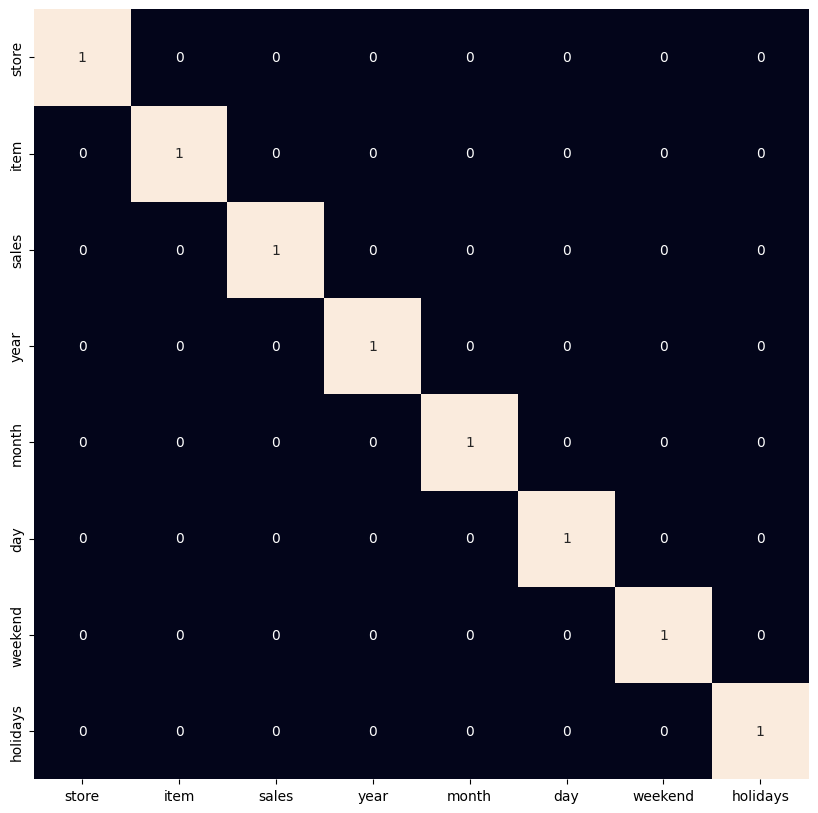

In [32]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()

In [33]:
df = df[df['sales']<140]

In [34]:
features = df.drop(['sales', 'year'], axis=1)
target = df['sales'].values

In [39]:
X_train, X_val, Y_train, Y_val = train_test_split(features, target,
                                                 test_size = 0.05, random_state=22)
X_train.shape, X_val.shape

((861170, 6), (45325, 6))

In [40]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [44]:
models = [LinearRegression(), XGBRegressor(), Lasso(), Ridge()]

for i in range(4):
    models[i].fit(X_train, Y_train)

    print(f'{models[i]} : ')

    train_preds = models[i].predict(X_train)
    print('Training Error : ', mse(Y_train, train_preds))

    val_preds = models[i].predict(X_val)
    print('Validation Error : ', mse(Y_val, val_preds))
    print()

LinearRegression() : 
Training Error :  733.9402790272612
Validation Error :  742.3583281532013

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) : 
Training Error :  100.71453857421875
Validation Error :  100.88817596435547

Lasso() : 
Training Error :  736.9990519004386
Validation Error :  744.257